In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
df = pd.read_csv("diabetes_dataset.csv")   # ← change path if needed

print("=" * 60)
print("DIABETES DATASET — NULL VALUE HANDLER")
print("=" * 60)
print(f"\n[1] Dataset Shape (before): {df.shape}")
print(f"    Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

# ─────────────────────────────────────────────
# 2. NULL REPORT
# ─────────────────────────────────────────────
null_counts = df.isnull().sum()
total_nulls = null_counts.sum()

print(f"\n[2] Total null values found: {total_nulls:,}")

null_cols = null_counts[null_counts > 0]
if null_cols.empty:
    print("\n    ✅ No null values detected in any column.")
    print("       The dataset is already null-free — no action needed.")
else:
    null_pct = (null_cols / len(df) * 100).round(2)
    null_report = pd.DataFrame({
        "Missing Count": null_cols,
        "Missing %"    : null_pct,
        "Dtype"        : df[null_cols.index].dtypes
    })
    print(f"\n    Columns with nulls ({len(null_cols)}):")
    print(null_report.to_string())

    # ── CRITICAL COLUMNS (drop row if null) ──────────────────
    CRITICAL = [
        "diabetes",             # target — row is useless without it
        "age",                  # core demographic
        "gender",               # core demographic
        "bmi",                  # key clinical indicator
        "hbA1c_level",          # primary diabetes marker
        "blood_glucose_level",  # primary diabetes marker
        "hypertension",         # major risk factor
        "heart_disease",        # major risk factor
    ]
    critical_existing = [c for c in CRITICAL if c in df.columns]
    critical_null     = [c for c in critical_existing if c in null_cols.index]

    if critical_null:
        before = len(df)
        df.dropna(subset=critical_null, inplace=True)
        dropped = before - len(df)
        print(f"\n    Dropped {dropped:,} rows with nulls in critical columns: {critical_null}")
    else:
        print("\n    No nulls found in critical columns — no rows dropped.")

    # ── REMAINING: column-level strategy ─────────────────────
    DROP_THRESHOLD = 50.0
    PROTECTED = ["diabetes"]

    remaining_nulls = df.isnull().sum()
    remaining_nulls = remaining_nulls[remaining_nulls > 0]
    remaining_pct   = (remaining_nulls / len(df) * 100).round(2)

    cols_to_drop   = remaining_pct[remaining_pct > DROP_THRESHOLD].index.tolist()
    cols_to_impute = remaining_pct[remaining_pct <= DROP_THRESHOLD].index.tolist()

    safe_to_drop = [c for c in cols_to_drop if c not in PROTECTED]
    df.drop(columns=safe_to_drop, inplace=True)

    for col in cols_to_impute:
        if col not in df.columns or col in PROTECTED:
            continue
        if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            mode_val = df[col].mode()
            if not mode_val.empty:
                df[col].fillna(mode_val[0], inplace=True)

# ─────────────────────────────────────────────
# 3. HIDDEN NULLS — check for disguised missing values
# ─────────────────────────────────────────────
print("\n[3] Checking for hidden/disguised null values...")

# Common disguised nulls in medical datasets
DISGUISED = ["Unknown", "unknown", "N/A", "n/a", "None", "none",
             "No Info", "no info", "not specified", "Not Specified", "-"]

hidden_found = False
for col in df.select_dtypes(include="object").columns:
    hits = df[col].isin(DISGUISED).sum()
    if hits > 0:
        print(f"    ⚠ '{col}': {hits:,} disguised nulls found ({DISGUISED}) → converted to NaN")
        df[col].replace(DISGUISED, np.nan, inplace=True)
        hidden_found = True

# Special case: smoking_history "No Info" is common in this dataset
if "smoking_history" in df.columns:
    no_info_count = (df["smoking_history"] == "No Info").sum()
    if no_info_count > 0:
        print(f"    ⚠ 'smoking_history': {no_info_count:,} 'No Info' entries → converted to NaN")
        df["smoking_history"].replace("No Info", np.nan, inplace=True)
        # Impute with mode (most frequent smoking category)
        mode_val = df["smoking_history"].mode()
        if not mode_val.empty:
            df["smoking_history"].fillna(mode_val[0], inplace=True)
            print(f"       Imputed with mode: '{mode_val[0]}'")
        hidden_found = True

if not hidden_found:
    print("    ✅ No disguised nulls found.")

# ─────────────────────────────────────────────
# 4. FINAL VERIFICATION
# ─────────────────────────────────────────────
final_nulls = df.isnull().sum().sum()
print(f"\n[4] Null values remaining after all cleaning: {final_nulls}")
print(f"\n[5] Summary:")
print(f"    Original shape : 100,000 rows × 16 columns")
print(f"    Final shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")

# ─────────────────────────────────────────────
# 5. SAVE
# ─────────────────────────────────────────────
df.to_csv("diabetes_cleaned.csv", index=False)
print(f"\n[6] Cleaned dataset saved to: 'diabetes_cleaned.csv'")
print("=" * 60)

DIABETES DATASET — NULL VALUE HANDLER

[1] Dataset Shape (before): (100000, 16)
    Rows: 100,000  |  Columns: 16

[2] Total null values found: 0

    ✅ No null values detected in any column.
       The dataset is already null-free — no action needed.

[3] Checking for hidden/disguised null values...
    ⚠ 'smoking_history': 35,816 disguised nulls found (['Unknown', 'unknown', 'N/A', 'n/a', 'None', 'none', 'No Info', 'no info', 'not specified', 'Not Specified', '-']) → converted to NaN

[4] Null values remaining after all cleaning: 35816

[5] Summary:
    Original shape : 100,000 rows × 16 columns
    Final shape    : 100,000 rows × 16 columns

[6] Cleaned dataset saved to: 'diabetes_cleaned.csv'


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df = pd.read_csv("diabetes_cleaned.csv")   # ← runs after null handler

print("=" * 60)
print("DIABETES DATASET — DUPLICATE HANDLER")
print("=" * 60)
print(f"\n[1] Dataset Shape (before): {df.shape}")
print(f"    Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

# ─────────────────────────────────────────────
# 2. WHY NO UNIQUE ID — EXPLANATION
# ─────────────────────────────────────────────
print("""
[2] Unique Identifier Check:
    This dataset has NO single unique identifier column.
    All columns have repeated values (e.g. age, gender, bmi).
    Strategy: use a COMPOSITE KEY — a combination of columns
    that together should uniquely identify one patient record.
""")

# ─────────────────────────────────────────────
# 3. FULL-ROW DUPLICATES
# ─────────────────────────────────────────────
full_dupes = df.duplicated().sum()
print(f"[3] Full-row duplicates (every column identical): {full_dupes:,}")

if full_dupes > 0:
    print("\n    Sample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(6).to_string())

df_clean = df.copy()
df_clean.drop_duplicates(inplace=True)
print(f"\n    After removing full-row duplicates: {len(df_clean):,} rows remaining")

# ─────────────────────────────────────────────
# 4. COMPOSITE KEY DUPLICATES
# ─────────────────────────────────────────────
# These columns together should uniquely represent one patient:
# same person cannot have two different records with identical
# age, gender, bmi, HbA1c, glucose, and all risk flags.

COMPOSITE_KEY = [
    "year",
    "age",
    "gender",
    "bmi",
    "hbA1c_level",
    "blood_glucose_level",
    "hypertension",
    "heart_disease",
    "smoking_history",
]

# Keep only composite key columns that exist in the dataset
composite_existing = [c for c in COMPOSITE_KEY if c in df_clean.columns]
print(f"\n[4] Composite key columns used ({len(composite_existing)}):")
for c in composite_existing:
    print(f"    - {c}")

composite_dupes = df_clean.duplicated(subset=composite_existing).sum()
composite_all   = df_clean[df_clean.duplicated(subset=composite_existing, keep=False)]

print(f"\n    Composite key duplicates found: {composite_dupes:,}")
print(f"    Total rows involved           : {len(composite_all):,}")

if composite_dupes > 0:
    print("\n    Sample conflict (first group):")
    first_conflict = composite_all.head(4)
    print(first_conflict.to_string())

    # Keep the row with the most non-null values (most complete)
    df_clean["_completeness"] = df_clean.notna().sum(axis=1)
    df_clean.sort_values("_completeness", ascending=False, inplace=True)
    df_clean.drop_duplicates(subset=composite_existing, keep="first", inplace=True)
    df_clean.drop(columns=["_completeness"], inplace=True)
    print(f"\n    After composite deduplication: {len(df_clean):,} rows remaining")
else:
    print("\n    ✅ No composite key duplicates found.")

# ─────────────────────────────────────────────
# 5. NEAR-DUPLICATE CHECK (same patient, tiny BMI rounding diff)
# ─────────────────────────────────────────────
print("\n[5] Near-Duplicate Check (BMI rounded to 1 decimal)...")

df_clean["bmi_rounded"] = df_clean["bmi"].round(1)

near_key = ["year", "age", "gender", "bmi_rounded",
            "hbA1c_level", "blood_glucose_level",
            "hypertension", "heart_disease"]
near_key_existing = [c for c in near_key if c in df_clean.columns]

near_dupes = df_clean.duplicated(subset=near_key_existing).sum()
print(f"    Near-duplicates (BMI rounded): {near_dupes:,}")

if near_dupes > 0:
    df_clean["_completeness"] = df_clean.notna().sum(axis=1)
    df_clean.sort_values("_completeness", ascending=False, inplace=True)
    df_clean.drop_duplicates(subset=near_key_existing, keep="first", inplace=True)
    df_clean.drop(columns=["_completeness"], inplace=True)
    print(f"    After near-duplicate removal: {len(df_clean):,} rows remaining")
else:
    print("    ✅ No near-duplicates found.")

df_clean.drop(columns=["bmi_rounded"], inplace=True)

# ─────────────────────────────────────────────
# 6. FINAL VERIFICATION
# ─────────────────────────────────────────────
final_full_dupes      = df_clean.duplicated().sum()
final_composite_dupes = df_clean.duplicated(subset=composite_existing).sum()
rows_removed          = len(df) - len(df_clean)

print(f"\n[6] Verification:")
print(f"    Full-row duplicates remaining     : {final_full_dupes}")
print(f"    Composite key duplicates remaining: {final_composite_dupes}")

print(f"\n[7] Summary:")
print(f"    Original  → {len(df):,} rows")
print(f"    Cleaned   → {len(df_clean):,} rows")
print(f"    Removed   → {rows_removed:,} duplicate rows")

# ─────────────────────────────────────────────
# 7. SAVE
# ─────────────────────────────────────────────
df_clean.to_csv("diabetes_final.csv", index=False)
print(f"\n[8] Final dataset saved to: 'diabetes_final.csv'")
print("=" * 60)

DIABETES DATASET — DUPLICATE HANDLER

[1] Dataset Shape (before): (100000, 16)
    Rows: 100,000  |  Columns: 16

[2] Unique Identifier Check:
    This dataset has NO single unique identifier column.
    All columns have repeated values (e.g. age, gender, bmi).
    Strategy: use a COMPOSITE KEY — a combination of columns
    that together should uniquely identify one patient record.

[3] Full-row duplicates (every column identical): 14

    Sample of duplicate rows:
       year  gender   age location  race:AfricanAmerican  race:Asian  race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease smoking_history    bmi  hbA1c_level  blood_glucose_level  diabetes
2782   2019    Male  40.0   Alaska                     0           0               1              0           0             0              0             NaN  27.32          6.2                   85         0
2848   2019    Male  40.0   Alaska                     0           0               1              0           0  

Loaded: 93,216 rows × 16 columns
PROBLEM STATEMENT

Can we predict whether a patient is diabetic based on their
medical history and demographic information?

Key questions investigated:
  Q1. How does age distribution differ between diabetic and non-diabetic patients?
  Q2. Does BMI play a significant role in diabetes onset?
  Q3. Which HbA1c and blood glucose levels indicate diabetes risk?
  Q4. Do hypertension and heart disease increase diabetes risk?
  Q5. How does smoking history relate to diabetes prevalence?
  Q6. Are there gender-based and racial differences in diabetes rates?

DATASET OVERVIEW

Shape     : (93216, 16)
Columns   : ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']

Target distribution (diabetes):
  No Diabetes: 84,843  (91.0%)
  Has Diabetes: 8,373  (9.0%)

Basic statistics:
       

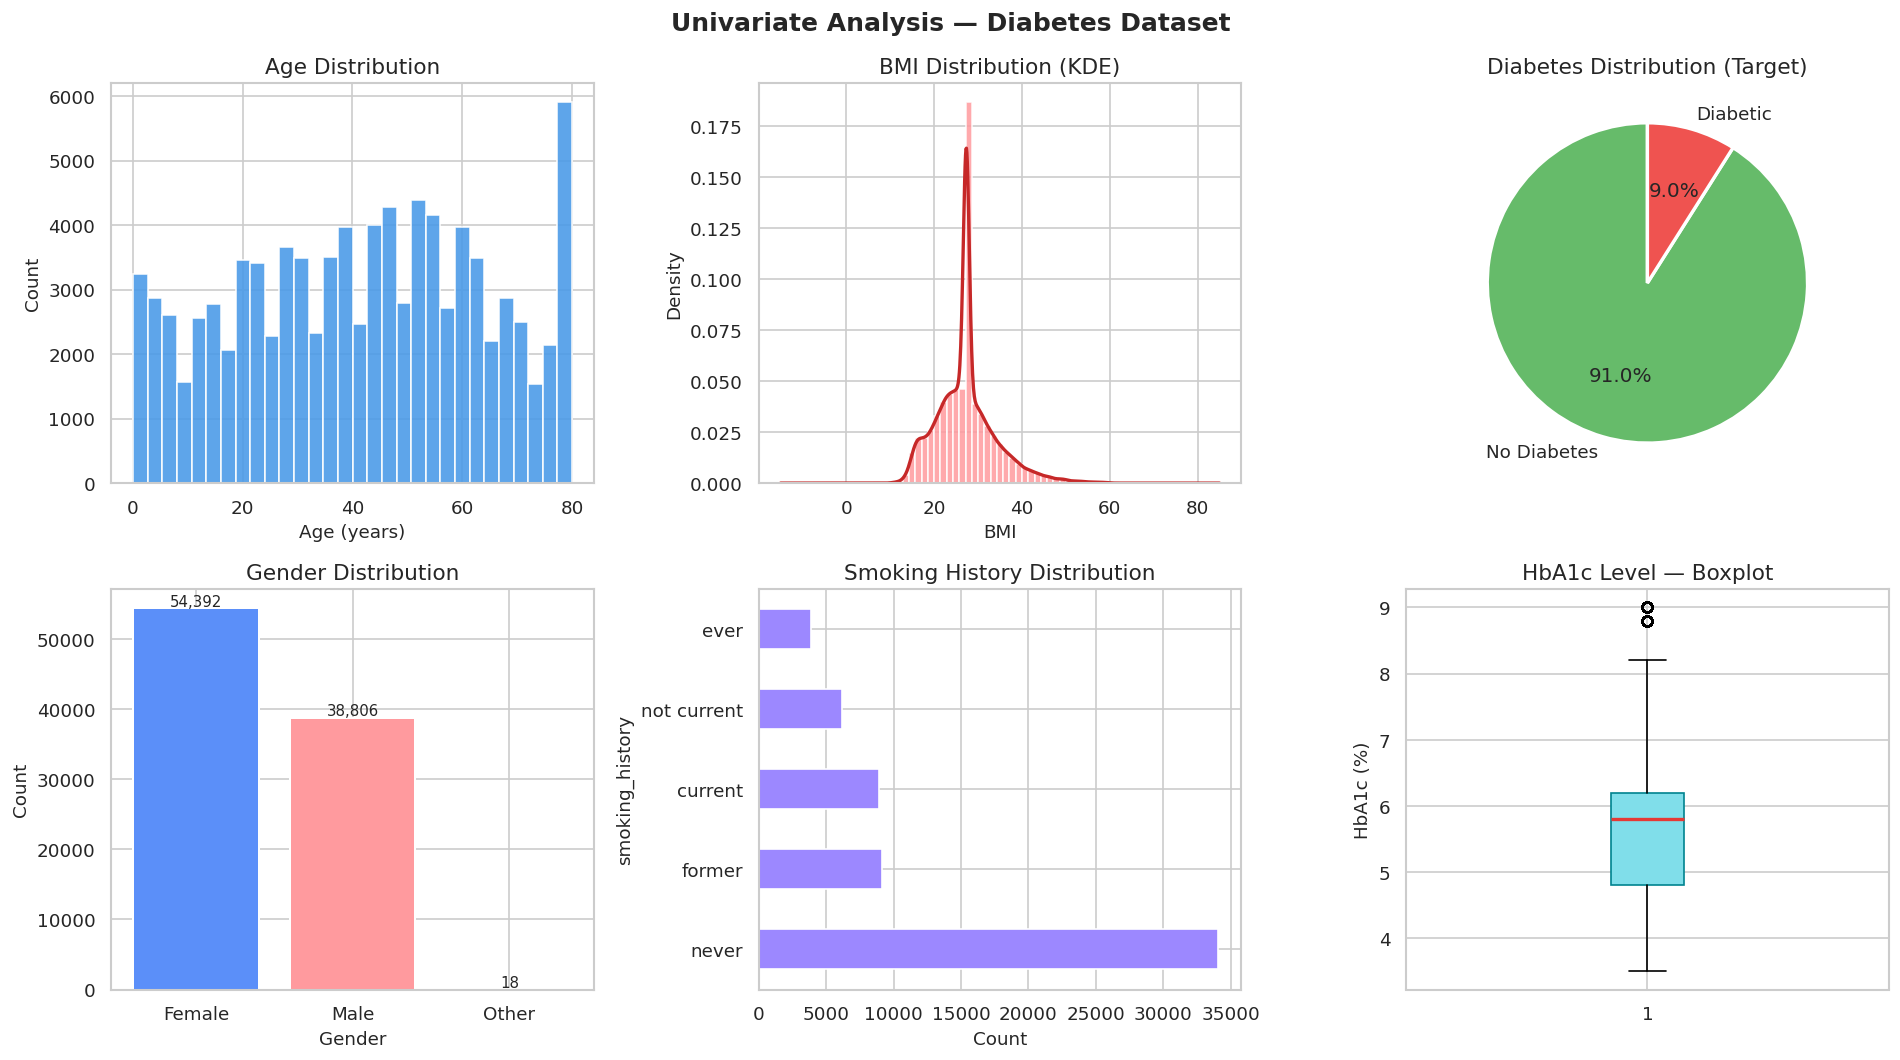

  Saved: plot_01_univariate.png

[EDA] Bivariate Analysis


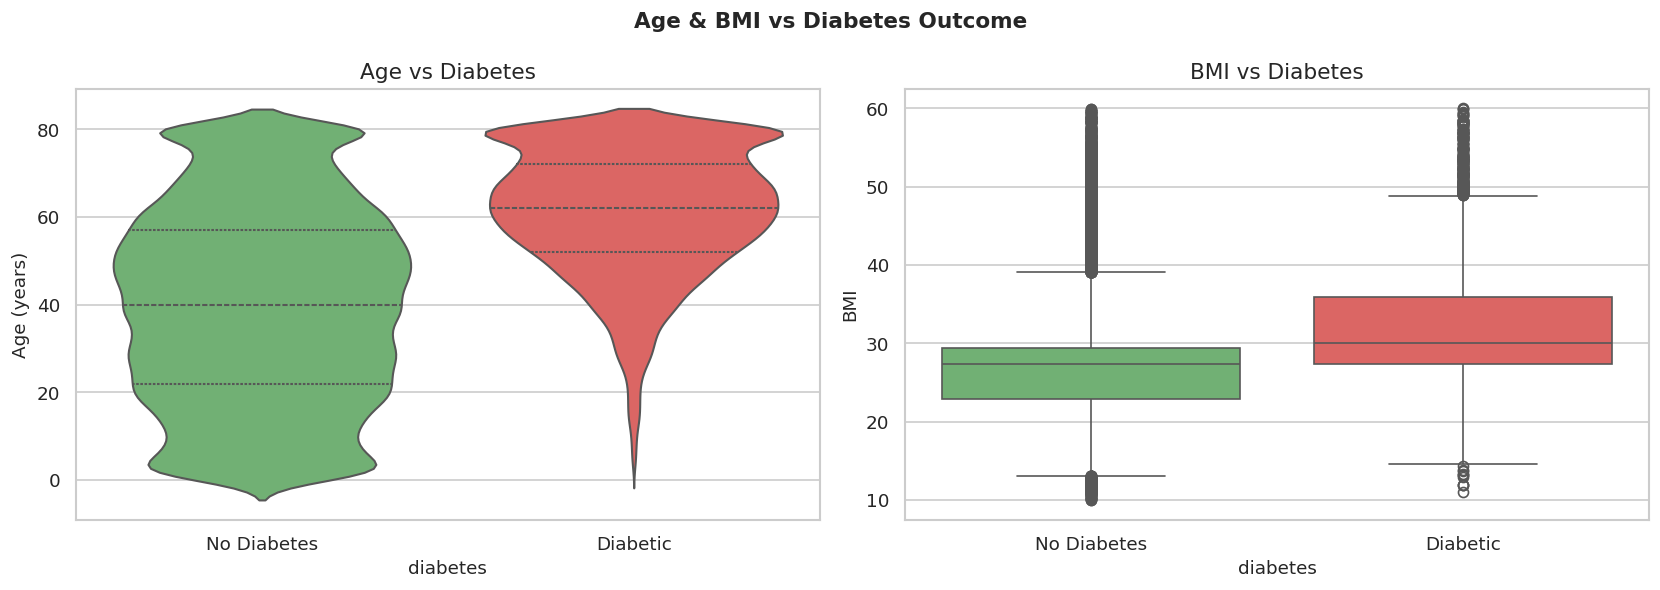

  Saved: plot_02_age_bmi_vs_diabetes.png


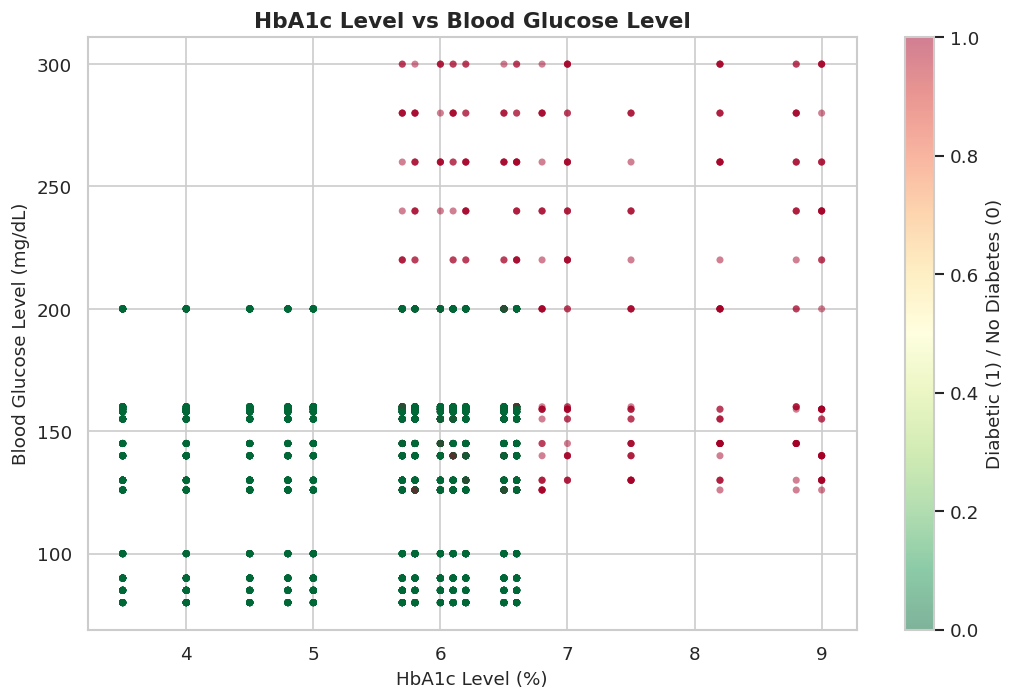

  Saved: plot_03_hba1c_glucose_scatter.png


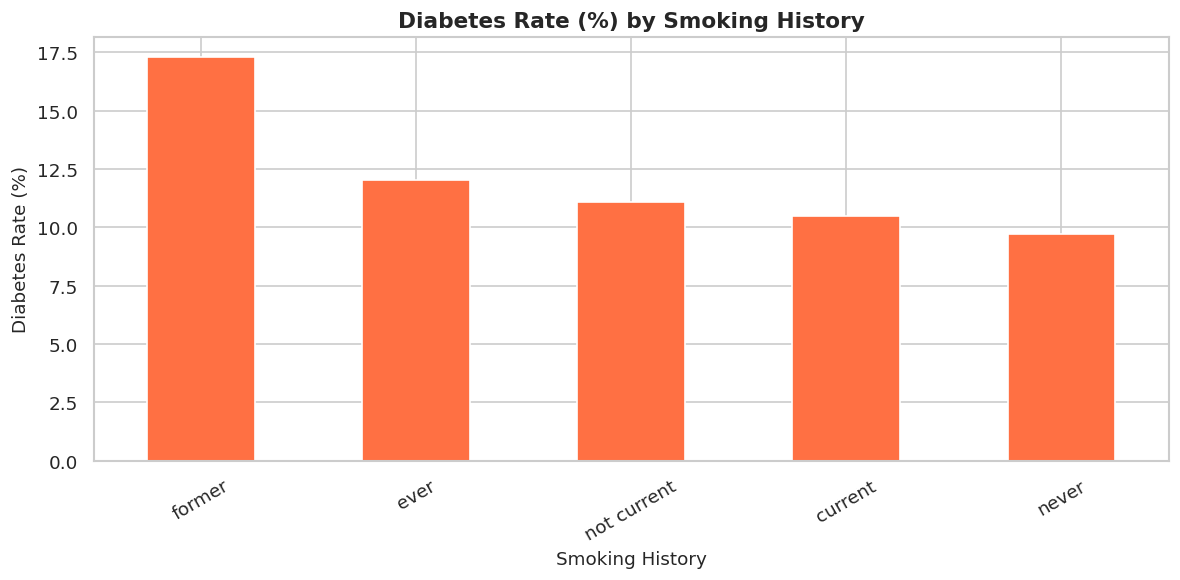

  Saved: plot_04_smoking_diabetes_rate.png

[EDA] Correlation Heatmap


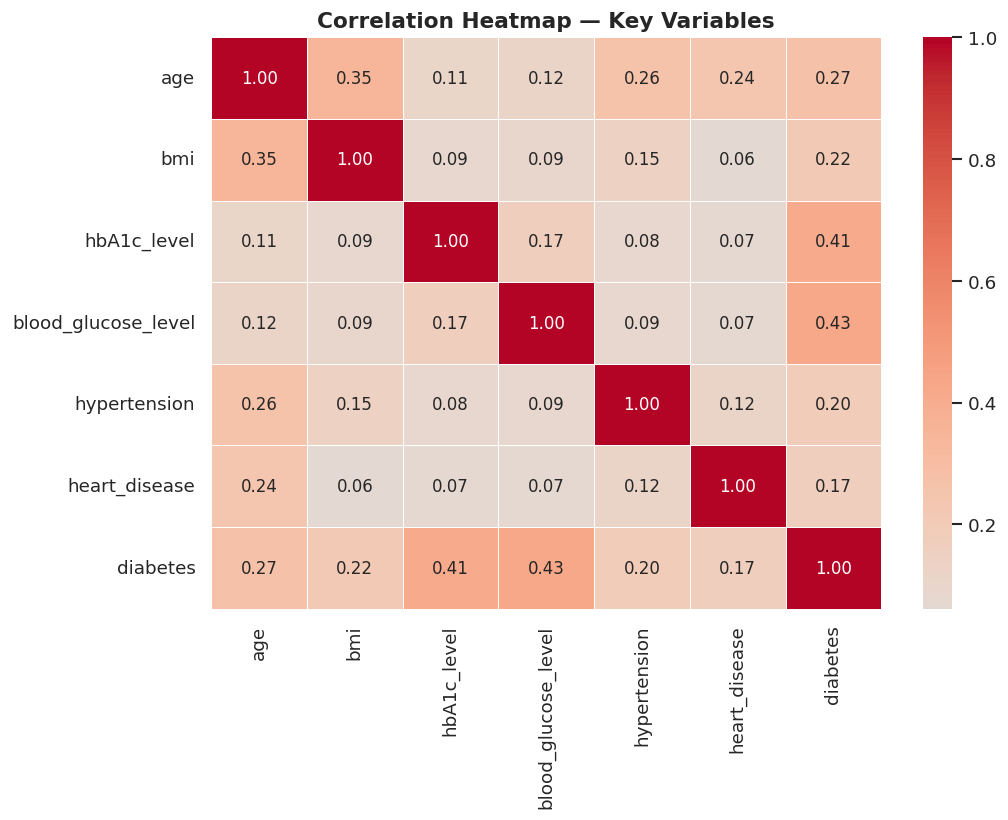

  Saved: plot_05_correlation_heatmap.png


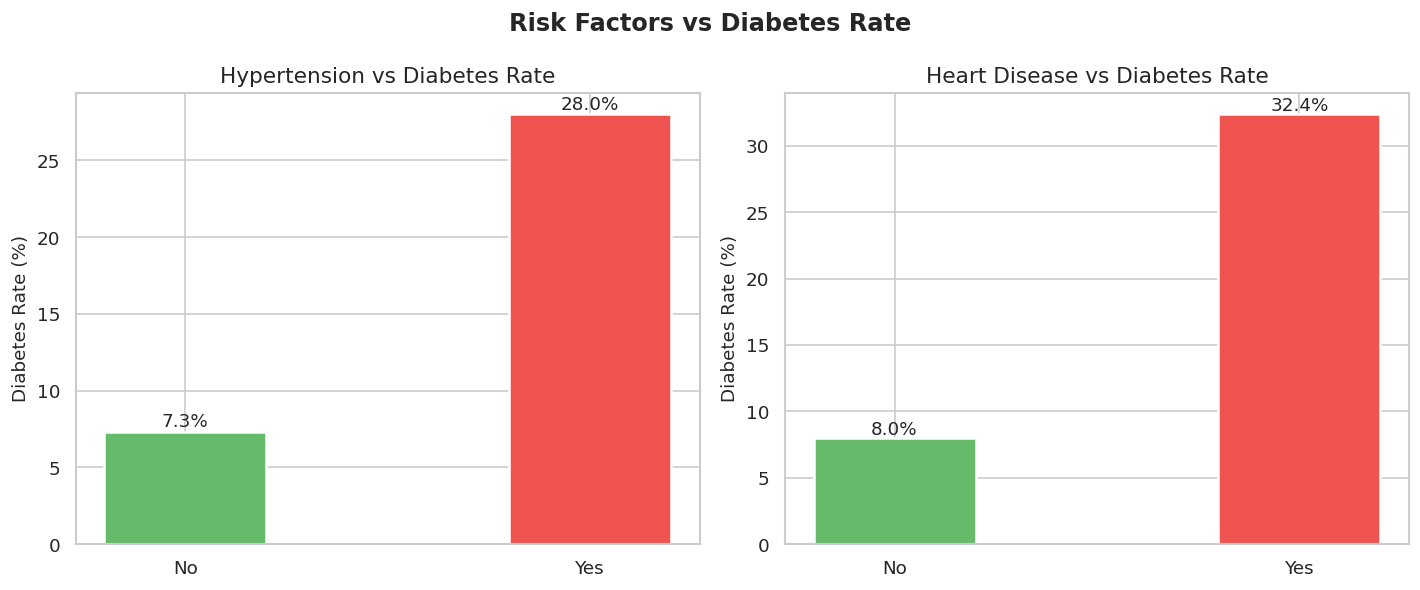

  Saved: plot_06_risk_factors.png


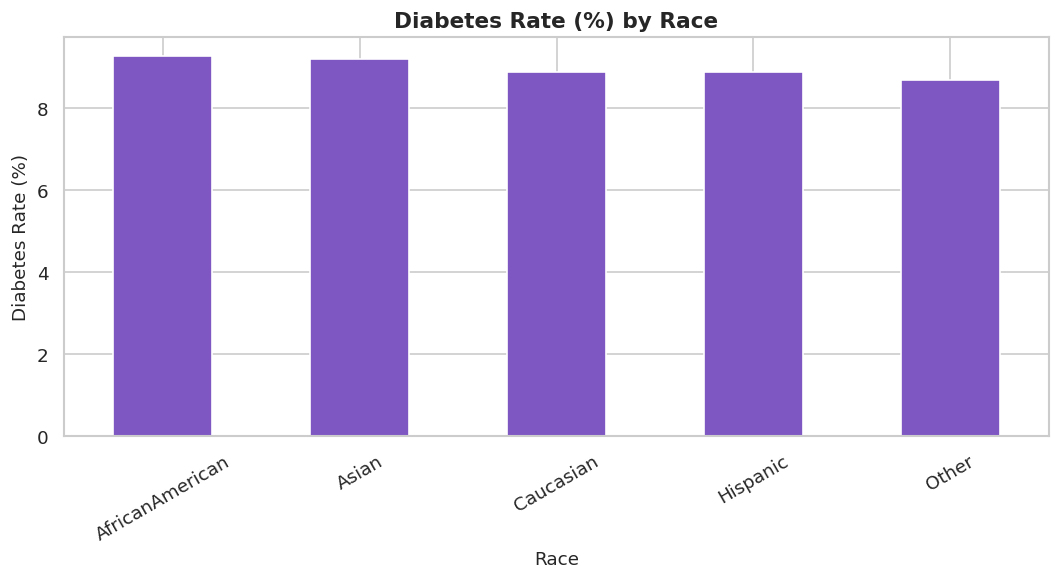

  Saved: plot_07_race_diabetes_rate.png

[EDA] Statistical Summary — Diabetic vs Non-Diabetic
------------------------------------------------------------

  age:
    No Diabetes → mean=39.78, std=22.33
    Diabetic    → mean=60.89, std=14.54
    t-test      → t=-84.735, p=0.0000  ✓ Significant

  bmi:
    No Diabetes → mean=26.87, std=6.60
    Diabetic    → mean=32.06, std=7.59
    t-test      → t=-67.662, p=0.0000  ✓ Significant

  hbA1c_level:
    No Diabetes → mean=5.40, std=0.97
    Diabetic    → mean=6.94, std=1.08
    t-test      → t=-137.713, p=0.0000  ✓ Significant

  blood_glucose_level:
    No Diabetes → mean=132.77, std=34.24
    Diabetic    → mean=194.47, std=58.73
    t-test      → t=-145.142, p=0.0000  ✓ Significant

✅ EDA complete. 7 plots saved.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.facecolor": "white"})

# ─────────────────────────────────────────────
# 0. LOAD
# ─────────────────────────────────────────────
def load_data(path="diabetes_final.csv"):
    df = pd.read_csv(path)
    print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df

# ─────────────────────────────────────────────
# 1. PROBLEM STATEMENT
# ─────────────────────────────────────────────
def print_problem_statement():
    print("=" * 65)
    print("PROBLEM STATEMENT")
    print("=" * 65)
    print("""
Can we predict whether a patient is diabetic based on their
medical history and demographic information?

Key questions investigated:
  Q1. How does age distribution differ between diabetic and non-diabetic patients?
  Q2. Does BMI play a significant role in diabetes onset?
  Q3. Which HbA1c and blood glucose levels indicate diabetes risk?
  Q4. Do hypertension and heart disease increase diabetes risk?
  Q5. How does smoking history relate to diabetes prevalence?
  Q6. Are there gender-based and racial differences in diabetes rates?
""")

# ─────────────────────────────────────────────
# 2. BASIC OVERVIEW
# ─────────────────────────────────────────────
def basic_overview(df):
    print("=" * 65)
    print("DATASET OVERVIEW")
    print("=" * 65)
    print(f"\nShape     : {df.shape}")
    print(f"Columns   : {df.columns.tolist()}")

    print(f"\nTarget distribution (diabetes):")
    counts = df["diabetes"].value_counts()
    pct    = df["diabetes"].value_counts(normalize=True) * 100
    for val, label in [(0, "No Diabetes"), (1, "Has Diabetes")]:
        print(f"  {label}: {counts[val]:,}  ({pct[val]:.1f}%)")

    print("\nBasic statistics:")
    print(df[["age","bmi","hbA1c_level","blood_glucose_level"]].describe().round(2).to_string())

# ─────────────────────────────────────────────
# 3. UNIVARIATE ANALYSIS — 6 variables
# ─────────────────────────────────────────────
def univariate_analysis(df):
    print("\n[EDA] Univariate Analysis")
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("Univariate Analysis — Diabetes Dataset", fontsize=15, fontweight="bold")

    # 1. Age — Histogram (Plot type 1)
    ax = axes[0, 0]
    ax.hist(df["age"].dropna(), bins=30, color="#4C9BE8", edgecolor="white", alpha=0.9)
    ax.set_title("Age Distribution")
    ax.set_xlabel("Age (years)"); ax.set_ylabel("Count")

    # 2. BMI — KDE + Histogram (Plot type 2)
    ax = axes[0, 1]
    bmi = df["bmi"].dropna()
    bmi = bmi[(bmi > 10) & (bmi < 60)]
    ax.hist(bmi, bins=35, color="#FF9A9E", edgecolor="white", alpha=0.85, density=True)
    bmi.plot.kde(ax=ax, color="#C62828", linewidth=2)
    ax.set_title("BMI Distribution (KDE)")
    ax.set_xlabel("BMI")

    # 3. Target — Pie Chart (Plot type 3)
    ax = axes[0, 2]
    counts = df["diabetes"].value_counts()
    ax.pie(counts, labels=["No Diabetes", "Diabetic"],
           autopct="%1.1f%%", colors=["#66BB6A", "#EF5350"],
           startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
    ax.set_title("Diabetes Distribution (Target)")

    # 4. Gender — Bar Chart (Plot type 4)
    ax = axes[1, 0]
    gender_counts = df["gender"].value_counts()
    bars = ax.bar(gender_counts.index, gender_counts.values,
                  color=["#5B8FF9", "#FF9A9E", "#A0C4FF"],
                  edgecolor="white", linewidth=1.2)
    ax.set_title("Gender Distribution")
    ax.set_xlabel("Gender"); ax.set_ylabel("Count")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{int(bar.get_height()):,}', ha='center', fontsize=9)

    # 5. Smoking History — Horizontal Bar
    ax = axes[1, 1]
    smoke_counts = df["smoking_history"].value_counts()
    smoke_counts.plot(kind="barh", ax=ax, color="#9C88FF", edgecolor="white")
    ax.set_title("Smoking History Distribution")
    ax.set_xlabel("Count")

    # 6. HbA1c Level — Boxplot (Plot type 5)
    ax = axes[1, 2]
    ax.boxplot(df["hbA1c_level"].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#80DEEA", color="#00838F"),
               medianprops=dict(color="#E53935", linewidth=2))
    ax.set_title("HbA1c Level — Boxplot")
    ax.set_ylabel("HbA1c (%)")

    plt.tight_layout()
    plt.savefig("plot_01_univariate.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_01_univariate.png")

# ─────────────────────────────────────────────
# 4. BIVARIATE ANALYSIS
# ─────────────────────────────────────────────
def bivariate_analysis(df):
    print("\n[EDA] Bivariate Analysis")

    # Plot A — Age & BMI vs Diabetes (Violin + Box) (Plot type 6)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Age & BMI vs Diabetes Outcome", fontsize=13, fontweight="bold")

    ax = axes[0]
    sns.violinplot(data=df, x="diabetes", y="age",
                   palette={'0': "#66BB6A", '1': "#EF5350"}, # Changed keys to strings
                   inner="quartile", ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No Diabetes", "Diabetic"])
    ax.set_title("Age vs Diabetes")
    ax.set_ylabel("Age (years)")

    ax = axes[1]
    bmi_clean = df[["diabetes","bmi"]].dropna()
    bmi_clean = bmi_clean[(bmi_clean["bmi"] > 10) & (bmi_clean["bmi"] < 60)]
    sns.boxplot(data=bmi_clean, x="diabetes", y="bmi",
                palette={'0': "#66BB6A", '1': "#EF5350"}, # Changed keys to strings
                ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No Diabetes", "Diabetic"])
    ax.set_title("BMI vs Diabetes")
    ax.set_ylabel("BMI")

    plt.tight_layout()
    plt.savefig("plot_02_age_bmi_vs_diabetes.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_02_age_bmi_vs_diabetes.png")

    # Plot B — HbA1c & Blood Glucose vs Diabetes (Scatter) (Plot type 7)
    fig, ax = plt.subplots(figsize=(9, 6))
    sample = df.sample(min(5000, len(df)), random_state=42)
    scatter = ax.scatter(sample["hbA1c_level"], sample["blood_glucose_level"],
                         c=sample["diabetes"], cmap="RdYlGn_r",
                         alpha=0.5, edgecolors="none", s=18)
    plt.colorbar(scatter, ax=ax, label="Diabetic (1) / No Diabetes (0)")
    ax.set_title("HbA1c Level vs Blood Glucose Level", fontweight="bold")
    ax.set_xlabel("HbA1c Level (%)"); ax.set_ylabel("Blood Glucose Level (mg/dL)")
    plt.tight_layout()
    plt.savefig("plot_03_hba1c_glucose_scatter.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_03_hba1c_glucose_scatter.png")

    # Plot C — Diabetes rate by smoking history (Bar)
    fig, ax = plt.subplots(figsize=(10, 5))
    smoke_rate = (df.groupby("smoking_history")["diabetes"]
                    .mean()
                    .sort_values(ascending=False) * 100)
    smoke_rate.plot(kind="bar", ax=ax, color="#FF7043", edgecolor="white")
    ax.set_title("Diabetes Rate (%) by Smoking History", fontweight="bold")
    ax.set_xlabel("Smoking History"); ax.set_ylabel("Diabetes Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig("plot_04_smoking_diabetes_rate.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_04_smoking_diabetes_rate.png")

    # Plot D — Correlation Heatmap (Plot type 8)
    print("\n[EDA] Correlation Heatmap")
    num_cols = ["age", "bmi", "hbA1c_level", "blood_glucose_level",
                "hypertension", "heart_disease", "diabetes"]
    existing = [c for c in num_cols if c in df.columns]
    corr = df[existing].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
    ax.set_title("Correlation Heatmap — Key Variables", fontweight="bold")
    plt.tight_layout()
    plt.savefig("plot_05_correlation_heatmap.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_05_correlation_heatmap.png")

    # Plot E — Hypertension & Heart Disease vs Diabetes rate
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Risk Factors vs Diabetes Rate", fontweight="bold")

    for ax, col, title in zip(axes,
                               ["hypertension", "heart_disease"],
                               ["Hypertension", "Heart Disease"]):
        rate = df.groupby(col)["diabetes"].mean() * 100
        labels = ["No", "Yes"]
        ax.bar(labels, rate.values, color=["#66BB6A", "#EF5350"],
               edgecolor="white", linewidth=1.5, width=0.4)
        ax.set_title(f"{title} vs Diabetes Rate")
        ax.set_ylabel("Diabetes Rate (%)")
        for i, v in enumerate(rate.values):
            ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)

    plt.tight_layout()
    plt.savefig("plot_06_risk_factors.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_06_risk_factors.png")

    # Plot F — Race vs Diabetes rate
    fig, ax = plt.subplots(figsize=(9, 5))
    race_cols = ["race:AfricanAmerican","race:Asian","race:Caucasian",
                 "race:Hispanic","race:Other"]
    race_cols = [c for c in race_cols if c in df.columns]
    race_rates = {}
    for col in race_cols:
        label = col.replace("race:", "")
        rate  = df[df[col] == 1]["diabetes"].mean() * 100
        race_rates[label] = rate

    race_series = pd.Series(race_rates).sort_values(ascending=False)
    race_series.plot(kind="bar", ax=ax, color="#7E57C2", edgecolor="white")
    ax.set_title("Diabetes Rate (%) by Race", fontweight="bold")
    ax.set_xlabel("Race"); ax.set_ylabel("Diabetes Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig("plot_07_race_diabetes_rate.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_07_race_diabetes_rate.png")

# ─────────────────────────────────────────────
# 5. STATISTICAL SUMMARY
# ─────────────────────────────────────────────
def statistical_summary(df):
    print("\n[EDA] Statistical Summary — Diabetic vs Non-Diabetic")
    print("-" * 60)
    for col in ["age", "bmi", "hbA1c_level", "blood_glucose_level"]:
        if col not in df.columns:
            continue
        no_diab = df[df["diabetes"] == 0][col].dropna()
        diabetic = df[df["diabetes"] == 1][col].dropna()
        t_stat, p_val = stats.ttest_ind(no_diab, diabetic)
        sig = "✓ Significant" if p_val < 0.05 else "✗ Not significant"
        print(f"\n  {col}:")
        print(f"    No Diabetes → mean={no_diab.mean():.2f}, std={no_diab.std():.2f}")
        print(f"    Diabetic    → mean={diabetic.mean():.2f}, std={diabetic.std():.2f}")
        print(f"    t-test      → t={t_stat:.3f}, p={p_val:.4f}  {sig}")

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    df = load_data()
    print_problem_statement()
    basic_overview(df)
    univariate_analysis(df)
    bivariate_analysis(df)
    statistical_summary(df)
    print("\n✅ EDA complete. 7 plots saved.")

Loaded: 93,216 rows × 16 columns

[FE] Creating new features...
  ✓ age_group          — Age binned into 5 clinical brackets
  ✓ bmi_category       — WHO BMI classification
  ✓ risk_score         — Weighted composite of HbA1c, glucose, BMI, age, comorbidities
  ✓ high_hba1c         — Binary: HbA1c ≥ 6.5% (clinical diabetes threshold)
  ✓ high_glucose       — Binary: blood glucose ≥ 200 mg/dL
  ✓ has_comorbidity    — Binary: has both hypertension AND heart disease
  ✓ is_senior          — Binary flag: age ≥ 60

  Dataset shape after engineering: (93216, 23)

[FE] Encoding & preparing features...
  Dropped non-predictive columns: ['year', 'location']
  Encoded: gender
  Encoded: smoking_history
  Encoded: age_group
  Encoded: bmi_category
  Saved: label_encoders.pkl

  Features : 20  |  Target: diabetes  |  Rows: 93,216

[Selection] METHOD A — Filter (ANOVA F-score / SelectKBest)
  Top 15 features by F-score:
risk_score             50619.31
blood_glucose_level    21066.18
hbA1c_level    

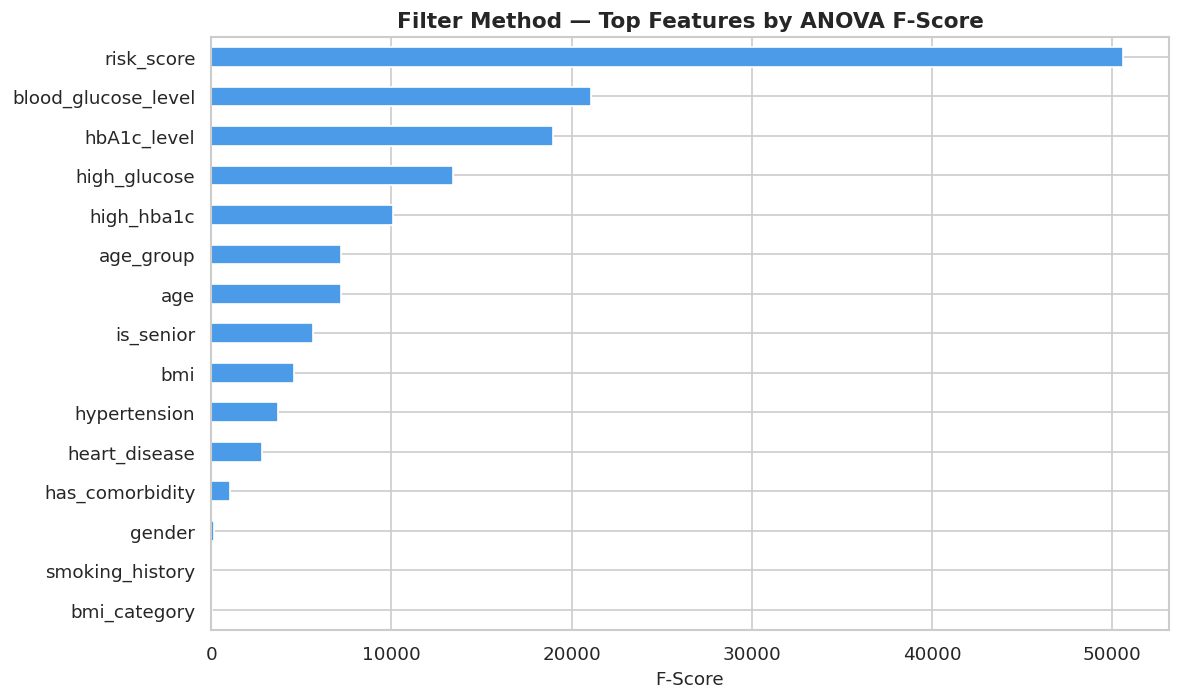

  Saved: plot_08_filter_selection.png

[Selection] METHOD B — Embedded (Random Forest Feature Importance)
  Top 15 features by RF importance:
risk_score              0.2947
hbA1c_level             0.2626
blood_glucose_level     0.1567
bmi                     0.0679
age                     0.0488
high_glucose            0.0315
smoking_history         0.0240
high_hba1c              0.0238
age_group               0.0184
is_senior               0.0096
gender                  0.0092
hypertension            0.0087
bmi_category            0.0069
race:AfricanAmerican    0.0062
race:Caucasian          0.0061


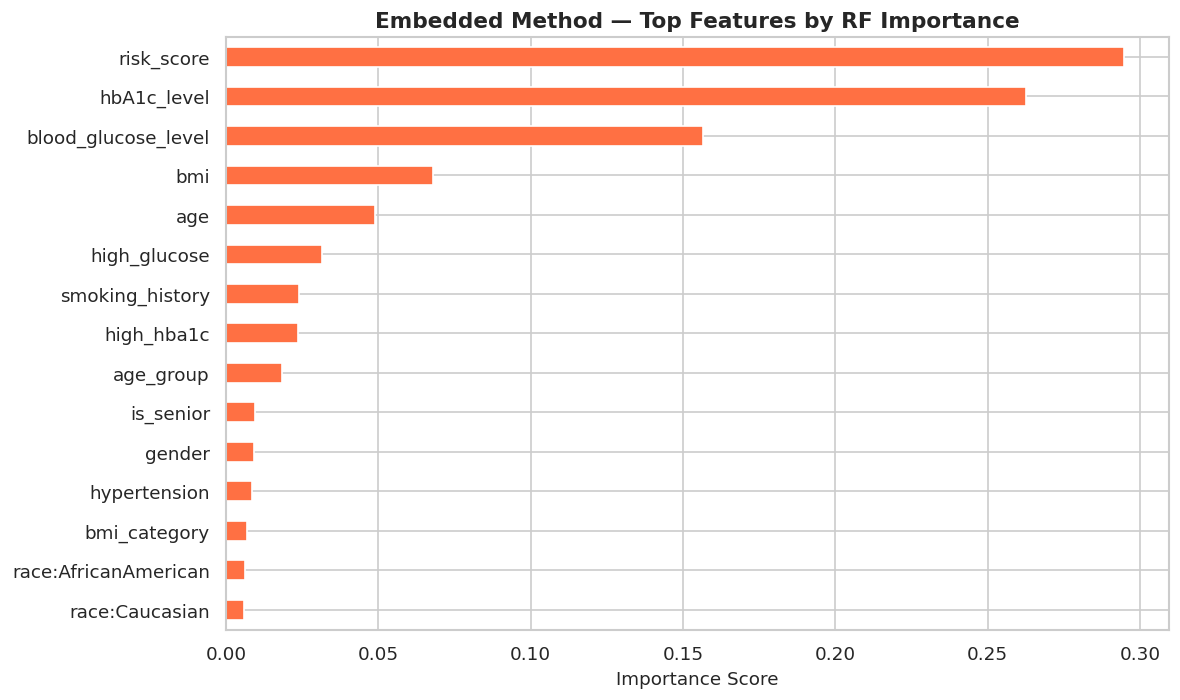

  Saved: plot_09_embedded_selection.png

[Selection] METHOD C — Wrapper (RFE — selecting 12 features)
  Selected 12 features via RFE:
    ✓ gender
    ✓ age
    ✓ race:AfricanAmerican
    ✓ race:Asian
    ✓ smoking_history
    ✓ bmi
    ✓ hbA1c_level
    ✓ blood_glucose_level
    ✓ age_group
    ✓ risk_score
    ✓ high_hba1c
    ✓ high_glucose

[Selection] Final Feature Set
  Total unique features selected: 18
    [Filter, Embedded, Wrapper     ]  risk_score
    [Filter, Embedded, Wrapper     ]  blood_glucose_level
    [Filter, Embedded, Wrapper     ]  hbA1c_level
    [Filter, Embedded, Wrapper     ]  high_glucose
    [Filter, Embedded, Wrapper     ]  high_hba1c
    [Filter, Embedded, Wrapper     ]  age_group
    [Filter, Embedded, Wrapper     ]  age
    [Filter, Embedded              ]  is_senior
    [Filter, Embedded, Wrapper     ]  bmi
    [Filter, Embedded              ]  hypertension
    [Filter                        ]  heart_disease
    [Filter                        ]  has_como

In [11]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0. LOAD
# ─────────────────────────────────────────────
def load_data(path="diabetes_final.csv"):
    df = pd.read_csv(path)
    print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df

# ─────────────────────────────────────────────
# 1. FEATURE ENGINEERING
# ─────────────────────────────────────────────
def engineer_features(df):
    print("\n[FE] Creating new features...")
    df = df.copy()

    # New Feature 1: Age Group — clinical age brackets
    df["age_group"] = pd.cut(df["age"],
                             bins=[0, 18, 35, 50, 65, 120],
                             labels=["0-18", "19-35", "36-50", "51-65", "65+"])
    print("  ✓ age_group          — Age binned into 5 clinical brackets")

    # New Feature 2: BMI Category — WHO standard classification
    df["bmi_category"] = pd.cut(df["bmi"],
                                bins=[0, 18.5, 25.0, 30.0, 100],
                                labels=["Underweight", "Normal", "Overweight", "Obese"])
    print("  ✓ bmi_category       — WHO BMI classification")

    # New Feature 3: Diabetes Risk Score
    # Combines key numeric risk factors into a single weighted score
    df["risk_score"] = (
        (df["hbA1c_level"] / df["hbA1c_level"].max()) * 0.35 +
        (df["blood_glucose_level"] / df["blood_glucose_level"].max()) * 0.35 +
        (df["bmi"] / df["bmi"].max()) * 0.15 +
        (df["age"] / df["age"].max()) * 0.10 +
        df["hypertension"] * 0.03 +
        df["heart_disease"] * 0.02
    ).round(4)
    print("  ✓ risk_score         — Weighted composite of HbA1c, glucose, BMI, age, comorbidities")

    # New Feature 4: High HbA1c flag (≥ 6.5% is diagnostic threshold for diabetes)
    df["high_hba1c"] = (df["hbA1c_level"] >= 6.5).astype(int)
    print("  ✓ high_hba1c         — Binary: HbA1c ≥ 6.5% (clinical diabetes threshold)")

    # New Feature 5: High Blood Glucose flag (≥ 200 mg/dL indicates diabetes)
    df["high_glucose"] = (df["blood_glucose_level"] >= 200).astype(int)
    print("  ✓ high_glucose       — Binary: blood glucose ≥ 200 mg/dL")

    # New Feature 6: Comorbidity flag (has BOTH hypertension and heart disease)
    df["has_comorbidity"] = ((df["hypertension"] == 1) & (df["heart_disease"] == 1)).astype(int)
    print("  ✓ has_comorbidity    — Binary: has both hypertension AND heart disease")

    # New Feature 7: Is Senior (age >= 60 — elevated diabetes risk group)
    df["is_senior"] = (df["age"] >= 60).astype(int)
    print("  ✓ is_senior          — Binary flag: age ≥ 60")

    print(f"\n  Dataset shape after engineering: {df.shape}")
    return df

# ─────────────────────────────────────────────
# 2. ENCODE & PREPARE
# ─────────────────────────────────────────────
def encode_and_prepare(df):
    print("\n[FE] Encoding & preparing features...")
    df = df.copy()

    # Drop columns not useful for modeling
    drop_cols = ["year", "location"]   # year is imbalanced; location too granular
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    print(f"  Dropped non-predictive columns: {drop_cols}")

    # Encode categorical columns
    le = LabelEncoder()
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    encoders = {}
    for col in cat_cols:
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        encoders[col] = le
        print(f"  Encoded: {col}")

    joblib.dump(encoders, "label_encoders.pkl")
    print("  Saved: label_encoders.pkl")

    df.dropna(inplace=True)

    X = df.drop(columns=["diabetes"])
    y = df["diabetes"]
    print(f"\n  Features : {X.shape[1]}  |  Target: diabetes  |  Rows: {len(y):,}")
    return X, y

# ─────────────────────────────────────────────
# 3. FEATURE SELECTION
# ─────────────────────────────────────────────

# ── Method A: Filter — ANOVA F-score ──
def filter_selection(X, y, k=15):
    print("\n[Selection] METHOD A — Filter (ANOVA F-score / SelectKBest)")
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

    print(f"  Top {k} features by F-score:")
    print(scores.head(k).round(2).to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    scores.head(k).sort_values().plot(kind="barh", ax=ax, color="#4C9BE8", edgecolor="white")
    ax.set_title("Filter Method — Top Features by ANOVA F-Score", fontweight="bold")
    ax.set_xlabel("F-Score")
    plt.tight_layout()
    plt.savefig("plot_08_filter_selection.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_08_filter_selection.png")

    return scores.head(k).index.tolist()

# ── Method B: Embedded — Random Forest Importance ──
def embedded_selection(X, y, top_n=15):
    print("\n[Selection] METHOD B — Embedded (Random Forest Feature Importance)")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    print(f"  Top {top_n} features by RF importance:")
    print(importance.head(top_n).round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    importance.head(top_n).sort_values().plot(kind="barh", ax=ax, color="#FF7043", edgecolor="white")
    ax.set_title("Embedded Method — Top Features by RF Importance", fontweight="bold")
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("plot_09_embedded_selection.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_09_embedded_selection.png")

    return importance.head(top_n).index.tolist()

# ── Method C: Wrapper — RFE ──
def wrapper_selection(X, y, n_features=12):
    print(f"\n[Selection] METHOD C — Wrapper (RFE — selecting {n_features} features)")
    scaler   = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42),
              n_features_to_select=n_features)
    rfe.fit(X_scaled, y)

    selected = X.columns[rfe.support_].tolist()
    print(f"  Selected {len(selected)} features via RFE:")
    for f in selected:
        print(f"    ✓ {f}")
    return selected

# ─────────────────────────────────────────────
# 4. FINAL FEATURE SET
# ─────────────────────────────────────────────
def final_feature_set(X, y, filter_f, embedded_f, wrapper_f):
    print("\n[Selection] Final Feature Set")
    # Union of all 3 methods, deduplicated, preserving order
    final = list(dict.fromkeys(filter_f + embedded_f + wrapper_f))
    final = [f for f in final if f in X.columns]

    print(f"  Total unique features selected: {len(final)}")
    for f in final:
        methods = []
        if f in filter_f:   methods.append("Filter")
        if f in embedded_f: methods.append("Embedded")
        if f in wrapper_f:  methods.append("Wrapper")
        print(f"    [{', '.join(methods):30s}]  {f}")

    # Save feature list for deployment
    joblib.dump(final, "feature_cols.pkl")
    print("\n  Saved: feature_cols.pkl")

    # Save final processed dataset
    X_final = X[final].copy()
    X_final["diabetes"] = y.values
    X_final.to_csv("diabetes_features.csv", index=False)
    print("  Saved: diabetes_features.csv")
    return final

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    df        = load_data()
    df        = engineer_features(df)
    X, y      = encode_and_prepare(df)
    filter_f  = filter_selection(X, y, k=15)
    emb_f     = embedded_selection(X, y, top_n=15)
    wrap_f    = wrapper_selection(X, y, n_features=12)
    final     = final_feature_set(X, y, filter_f, emb_f, wrap_f)
    print("\n✅ Feature engineering & selection complete.")


Loaded: 93,216 rows × 18 features
Train: 74,572  |  Test: 18,644
Saved: scaler.pkl

WHAT IS VALIDATION AND WHY IS IT IMPORTANT?

Validation is evaluating a trained model on data it has NEVER
seen during training, to estimate real-world generalization.

Why it matters for this diabetes dataset:
  1. OVERFITTING DETECTION: with 100,000 rows and engineered
     features like risk_score and high_hba1c, a model could
     memorize patterns instead of learning them. Validation
     exposes this early.
  2. CLASS IMBALANCE AWARENESS: only 8.5% of patients are
     diabetic. Accuracy alone is misleading (a model predicting
     "no diabetes" every time gets 91.5% accuracy but is useless).
     Validation with precision & recall reveals the truth.
  3. MODEL SELECTION: cross-validation compares all 3 algorithms
     fairly across multiple data splits — not just one lucky split.
  4. CLINICAL TRUST: a diabetes prediction tool must generalize
     beyond the training sample to be trusted by pract

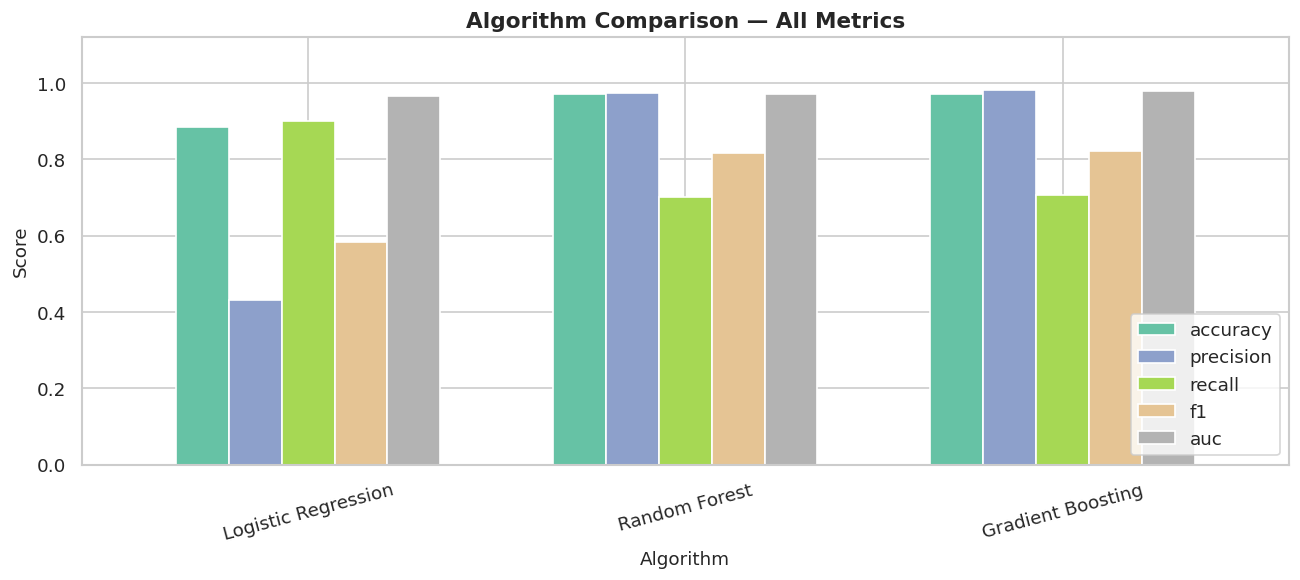


  Saved: plot_10_model_comparison.png

  Best algorithm by F1-Score: Gradient Boosting

[Tuning] GridSearchCV on: Gradient Boosting

WHAT IS PARAMETER TUNING AND WHY IS IT IMPORTANT?

Hyperparameters are settings configured BEFORE training — not
learned from the data. Examples: n_estimators, max_depth,
learning_rate, class_weight.

Why tuning matters for this diabetes dataset:
  1. CLASS IMBALANCE (8.5% diabetic): tuning class_weight or
     threshold dramatically improves recall for diabetic patients,
     which matters most clinically — missing a diabetic patient
     is far costlier than a false positive.
  2. OVERFITTING CONTROL: max_depth and min_samples_leaf prevent
     the model from memorizing the training data.
  3. OPTIMAL BALANCE: GridSearchCV tests all combinations using
     cross-validation, picking the one that maximizes F1 —
     which balances precision and recall for imbalanced data.

GridSearchCV exhaustively evaluates every parameter combination
across all CV fold

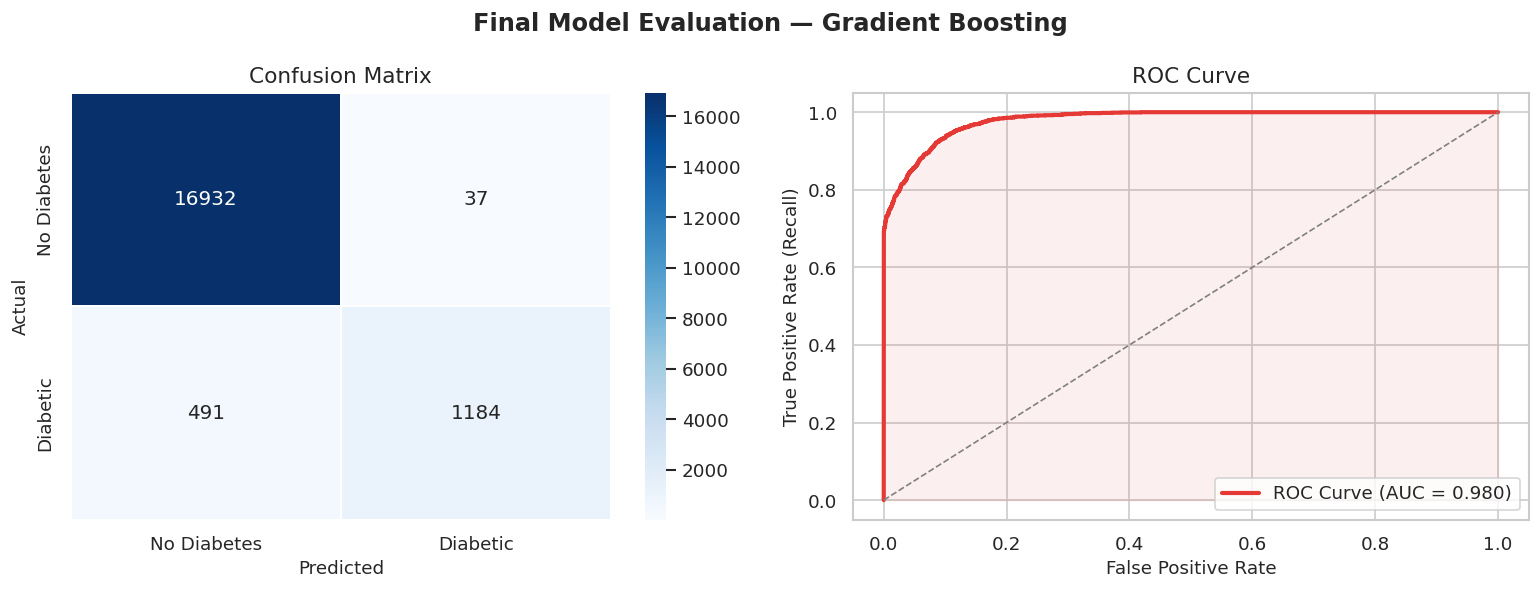

  Saved: plot_11_evaluation.png

✅ Model saved: diabetes_model.pkl

🎯 Files saved: diabetes_model.pkl | scaler.pkl | plot_11_evaluation.png


In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import joblib
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0. LOAD
# ─────────────────────────────────────────────
def load_data(path="diabetes_features.csv"):
    df = pd.read_csv(path)
    X  = df.drop(columns=["diabetes"])
    y  = df["diabetes"]
    print(f"Loaded: {X.shape[0]:,} rows × {X.shape[1]} features")
    return X, y

# ─────────────────────────────────────────────
# 1. SPLIT & SCALE
# ─────────────────────────────────────────────
def split_and_scale(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler  = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

    joblib.dump(scaler, "scaler.pkl")
    print(f"Train: {X_train_s.shape[0]:,}  |  Test: {X_test_s.shape[0]:,}")
    print("Saved: scaler.pkl")
    return X_train_s, X_test_s, y_train, y_test

# ─────────────────────────────────────────────
# 2. VALIDATION DISCUSSION
# ─────────────────────────────────────────────
def print_validation_explanation():
    print("\n" + "=" * 65)
    print("WHAT IS VALIDATION AND WHY IS IT IMPORTANT?")
    print("=" * 65)
    print("""
Validation is evaluating a trained model on data it has NEVER
seen during training, to estimate real-world generalization.

Why it matters for this diabetes dataset:
  1. OVERFITTING DETECTION: with 100,000 rows and engineered
     features like risk_score and high_hba1c, a model could
     memorize patterns instead of learning them. Validation
     exposes this early.
  2. CLASS IMBALANCE AWARENESS: only 8.5% of patients are
     diabetic. Accuracy alone is misleading (a model predicting
     "no diabetes" every time gets 91.5% accuracy but is useless).
     Validation with precision & recall reveals the truth.
  3. MODEL SELECTION: cross-validation compares all 3 algorithms
     fairly across multiple data splits — not just one lucky split.
  4. CLINICAL TRUST: a diabetes prediction tool must generalize
     beyond the training sample to be trusted by practitioners.

Techniques used:
  • Stratified Train/Test Split (80/20) — preserves 8.5% diabetic ratio
  • 5-Fold Cross-Validation — robust average performance estimate
  • Held-out Test Set — final unbiased evaluation
""")

# ─────────────────────────────────────────────
# 3. TRAIN & COMPARE 3 ALGORITHMS
# ─────────────────────────────────────────────
def train_and_compare(X_train, X_test, y_train, y_test):
    print("\n[Model] Training 3 algorithms...")

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, random_state=42, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, random_state=42),
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        cv_f1  = cross_val_score(model, X_train, y_train, cv=5,
                                  scoring="f1", n_jobs=-1)
        results[name] = {
            "model"    : model,
            "y_pred"   : y_pred,
            "y_prob"   : y_prob,
            "accuracy" : accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall"   : recall_score(y_test, y_pred, zero_division=0),
            "f1"       : f1_score(y_test, y_pred, zero_division=0),
            "auc"      : roc_auc_score(y_test, y_prob),
            "cv_f1"    : cv_f1.mean(),
            "cv_std"   : cv_f1.std(),
        }
        print(f"\n  ── {name} ──")
        print(f"    Accuracy  : {results[name]['accuracy']:.4f}")
        print(f"    Precision : {results[name]['precision']:.4f}")
        print(f"    Recall    : {results[name]['recall']:.4f}")
        print(f"    F1-Score  : {results[name]['f1']:.4f}")
        print(f"    AUC-ROC   : {results[name]['auc']:.4f}")
        print(f"    CV F1     : {results[name]['cv_f1']:.4f} ± {results[name]['cv_std']:.4f}")

    # Comparison chart
    metrics = ["accuracy", "precision", "recall", "f1", "auc"]
    comp_df = pd.DataFrame({n: [r[m] for m in metrics]
                             for n, r in results.items()}, index=metrics)
    fig, ax = plt.subplots(figsize=(11, 5))
    comp_df.T.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.7)
    ax.set_title("Algorithm Comparison — All Metrics", fontweight="bold")
    ax.set_xlabel("Algorithm"); ax.set_ylabel("Score")
    ax.set_ylim(0, 1.12); ax.legend(loc="lower right")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig("plot_10_model_comparison.png", bbox_inches="tight")
    plt.show()
    print("\n  Saved: plot_10_model_comparison.png")

    best_name = max(results, key=lambda k: results[k]["f1"])
    print(f"\n  Best algorithm by F1-Score: {best_name}")
    return results, best_name

# ─────────────────────────────────────────────
# 4. PARAMETER TUNING
# ─────────────────────────────────────────────
def print_tuning_explanation():
    print("\n" + "=" * 65)
    print("WHAT IS PARAMETER TUNING AND WHY IS IT IMPORTANT?")
    print("=" * 65)
    print("""
Hyperparameters are settings configured BEFORE training — not
learned from the data. Examples: n_estimators, max_depth,
learning_rate, class_weight.

Why tuning matters for this diabetes dataset:
  1. CLASS IMBALANCE (8.5% diabetic): tuning class_weight or
     threshold dramatically improves recall for diabetic patients,
     which matters most clinically — missing a diabetic patient
     is far costlier than a false positive.
  2. OVERFITTING CONTROL: max_depth and min_samples_leaf prevent
     the model from memorizing the training data.
  3. OPTIMAL BALANCE: GridSearchCV tests all combinations using
     cross-validation, picking the one that maximizes F1 —
     which balances precision and recall for imbalanced data.

GridSearchCV exhaustively evaluates every parameter combination
across all CV folds, then selects the configuration with the
best average score.
""")

def tune_best_model(X_train, X_test, y_train, y_test, best_name):
    print(f"\n[Tuning] GridSearchCV on: {best_name}")
    print_tuning_explanation()

    param_grids = {
        "Random Forest": {
            "n_estimators"    : [100, 200],
            "max_depth"       : [None, 10, 20],
            "min_samples_leaf": [1, 2],
            "class_weight"    : ["balanced", None]
        },
        "Gradient Boosting": {
            "n_estimators" : [100, 200],
            "max_depth"    : [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample"    : [0.8, 1.0]
        },
        "Logistic Regression": {
            "C"           : [0.01, 0.1, 1, 10],
            "penalty"     : ["l1", "l2"],
            "solver"      : ["liblinear"],
            "class_weight": ["balanced", None]
        }
    }

    base_models = {
        "Random Forest"      : RandomForestClassifier(random_state=42, n_jobs=-1),
        "Gradient Boosting"  : GradientBoostingClassifier(random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    }

    grid = GridSearchCV(
        estimator=base_models[best_name],
        param_grid=param_grids[best_name],
        cv=5, scoring="f1", n_jobs=-1, verbose=1
    )
    grid.fit(X_train, y_train)

    print(f"\n  Best parameters : {grid.best_params_}")
    print(f"  Best CV F1      : {grid.best_score_:.4f}")

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    print(f"\n  Tuned Model — Test Set Metrics:")
    print(f"    Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"    Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"    F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"    AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred,
                                target_names=["No Diabetes", "Diabetic"]))
    return best_model, y_pred, y_prob

# ─────────────────────────────────────────────
# 5. EVALUATE — Confusion Matrix + ROC Curve
# ─────────────────────────────────────────────
def evaluate_final_model(best_model, X_test, y_test, y_pred, y_prob, model_name):
    print("\n[Eval] Generating evaluation plots...")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Final Model Evaluation — {model_name}", fontweight="bold")

    # Confusion Matrix
    ax = axes[0]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetic"],
                yticklabels=["No Diabetes", "Diabetic"],
                linewidths=1, linecolor="white")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    # ROC Curve
    ax = axes[1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val     = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color="#E53935", linewidth=2.5,
            label=f"ROC Curve (AUC = {auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "gray", linestyle="--", linewidth=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color="#E53935")
    ax.set_title("ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.savefig("plot_11_evaluation.png", bbox_inches="tight")
    plt.show()
    print("  Saved: plot_11_evaluation.png")

# ─────────────────────────────────────────────
# 6. SAVE MODEL
# ─────────────────────────────────────────────
def save_model(model):
    joblib.dump(model, "diabetes_model.pkl")
    print("\n✅ Model saved: diabetes_model.pkl")

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    X, y = load_data()
    X_train, X_test, y_train, y_test = split_and_scale(X, y)
    print_validation_explanation()
    results, best_name = train_and_compare(X_train, X_test, y_train, y_test)
    best_model, y_pred, y_prob = tune_best_model(X_train, X_test, y_train, y_test, best_name)
    evaluate_final_model(best_model, X_test, y_test, y_pred, y_prob, best_name)
    save_model(best_model)
    print("\n🎯 Files saved: diabetes_model.pkl | scaler.pkl | plot_11_evaluation.png")

In [17]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(
    page_title="Diabetes Risk Predictor",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

@st.cache_resource
def load_artifacts():
    model        = joblib.load("diabetes_model.pkl")
    scaler       = joblib.load("scaler.pkl")
    feature_cols = joblib.load("feature_cols.pkl")
    return model, scaler, feature_cols

model, scaler, feature_cols = load_artifacts()

st.title("🩺 Diabetes Risk Predictor")
st.markdown("""
> Predict the likelihood of **diabetes** based on a patient\'s
> medical history and demographic information.
>
> *For educational purposes only — not a substitute for clinical diagnosis.*
""")
st.divider()

st.sidebar.header("👤 Patient Information")
st.sidebar.markdown("Enter the patient\'s details below:")

def get_user_input():
    age             = st.sidebar.slider("Age (years)", 0, 80, 45)
    gender          = st.sidebar.selectbox("Gender", ["Female", "Male", "Other"])
    bmi             = st.sidebar.number_input("BMI", 10.0, 95.0, 27.0, step=0.5)
    hba1c           = st.sidebar.number_input("HbA1c Level (%)", 3.5, 9.0, 5.5, step=0.1)
    blood_glucose   = st.sidebar.number_input("Blood Glucose Level (mg/dL)", 80, 300, 120)
    hypertension    = st.sidebar.selectbox("Hypertension?", ["No", "Yes"])
    heart_disease   = st.sidebar.selectbox("Heart Disease?", ["No", "Yes"])
    smoking_history = st.sidebar.selectbox("Smoking History",
                                           ["never", "former", "current",
                                            "not current", "ever", "No Info"])
    race = st.sidebar.selectbox("Race", ["AfricanAmerican", "Asian", "Caucasian",
                                         "Hispanic", "Other"])
    race_aa = 1 if race == "AfricanAmerican" else 0
    race_as = 1 if race == "Asian"           else 0
    race_ca = 1 if race == "Caucasian"       else 0
    race_hi = 1 if race == "Hispanic"        else 0
    race_ot = 1 if race == "Other"           else 0

    gender_map  = {"Female": 0, "Male": 1, "Other": 2}
    smoke_map   = {"No Info": 0, "current": 1, "ever": 2,
                   "former": 3, "never": 4, "not current": 5}
    hypert_val  = 1 if hypertension == "Yes" else 0
    heart_val   = 1 if heart_disease == "Yes" else 0

    age_group_val = (0 if age <= 18 else 1 if age <= 35 else
                     2 if age <= 50 else 3 if age <= 65 else 4)
    bmi_cat_val   = (0 if bmi < 18.5 else 1 if bmi < 25 else
                     2 if bmi < 30 else 3)
    risk_score    = round(
        (hba1c / 9.0) * 0.35 +
        (blood_glucose / 300) * 0.35 +
        (bmi / 95.0) * 0.15 +
        (age / 80.0) * 0.10 +
        hypert_val * 0.03 +
        heart_val  * 0.02, 4)
    high_hba1c   = 1 if hba1c >= 6.5 else 0
    high_glucose = 1 if blood_glucose >= 200 else 0
    has_comorbid = 1 if (hypert_val == 1 and heart_val == 1) else 0
    is_senior    = 1 if age >= 60 else 0

    data = {
        "gender"             : gender_map.get(gender, 0),
        "age"                : age,
        "race:AfricanAmerican": race_aa,
        "race:Asian"         : race_as,
        "race:Caucasian"     : race_ca,
        "race:Hispanic"      : race_hi,
        "race:Other"         : race_ot,
        "hypertension"       : hypert_val,
        "heart_disease"      : heart_val,
        "smoking_history"    : smoke_map.get(smoking_history, 0),
        "bmi"                : bmi,
        "hbA1c_level"        : hba1c,
        "blood_glucose_level": blood_glucose,
        "age_group"          : age_group_val,
        "bmi_category"       : bmi_cat_val,
        "risk_score"         : risk_score,
        "high_hba1c"         : high_hba1c,
        "high_glucose"       : high_glucose,
        "has_comorbidity"    : has_comorbid,
        "is_senior"          : is_senior,
    }
    return pd.DataFrame([data])

input_df = get_user_input()

for col in feature_cols:
    if col not in input_df.columns:
        input_df[col] = 0
input_df = input_df[feature_cols]

col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📋 Patient Input Summary")
    st.dataframe(input_df.T.rename(columns={0: "Value"}), use_container_width=True)

with col2:
    st.subheader("🔮 Prediction Result")
    try:
        input_scaled = scaler.transform(input_df)
        prediction   = model.predict(input_scaled)[0]
        probability  = model.predict_proba(input_scaled)[0]

        no_diab_pct = probability[0] * 100
        diab_pct    = probability[1] * 100

        if prediction == 0:
            st.success("✅ Prediction: **No Diabetes Detected**")
        else:
            st.error("⚠️ Prediction: **Diabetes Risk Detected**")

        st.markdown("#### Confidence Scores")
        col_a, col_b = st.columns(2)
        col_a.metric("No Diabetes", f"{no_diab_pct:.1f}%")
        col_b.metric("Diabetic",    f"{diab_pct:.1f}%")

        if diab_pct < 20:
            risk = "🟢 Low Risk"
        elif diab_pct < 50:
            risk = "🟡 Moderate Risk"
        else:
            risk = "🔴 High Risk"

        st.markdown(f"#### Risk Level: {risk}")
        st.progress(int(diab_pct))

        st.markdown("#### Key Risk Indicators")
        st.write(f"- **HbA1c ≥ 6.5%**: {\'⚠️ Yes\' if input_df[\'high_hba1c\'].values[0] == 1 else \'✅ No\'}")
        st.write(f"- **Blood Glucose ≥ 200 mg/dL**: {\'⚠️ Yes\' if input_df[\'high_glucose\'].values[0] == 1 else \'✅ No\'}")
        st.write(f"- **Has Comorbidity**: {\'⚠️ Yes\' if input_df[\'has_comorbidity\'].values[0] == 1 else \'✅ No\'}")
        st.write(f"- **Senior (≥60)**: {\'⚠️ Yes\' if input_df[\'is_senior\'].values[0] == 1 else \'✅ No\'}")

    except Exception as e:
        st.warning(f"Prediction error: {e}")
        st.info("Ensure diabetes_model.pkl, scaler.pkl, feature_cols.pkl are in the same folder.")

st.divider()
st.markdown("""
**Dataset:** Diabetes Prediction — Kaggle | 100,000 rows × 16 columns
**Model:** Tuned via GridSearchCV with 5-fold stratified cross-validation
**Metrics:** Precision, Recall, F1-Score, AUC-ROC
*For educational use only.*
""")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created successfully!")

✅ app.py created successfully!


In [14]:
with open("requirements.txt", "w") as f:
    f.write("""streamlit
pandas
numpy
scikit-learn
joblib""")

print("requirements.txt created!")

requirements.txt created!


In [18]:
import os
print(os.path.exists("app.py"))  # Should print: True

True


In [22]:
from google.colab import files

files.download("app.py")
files.download("diabetes_model.pkl")
files.download("scaler.pkl")
files.download("feature_cols.pkl")
files.download("label_encoders.pkl")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>